In [26]:
import numpy as np
import matplotlib.pyplot as plt
# Scipy and related modules
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks, find_peaks_cwt, peak_prominences

y = np.array([ 0.02687641  , -0.051838174 , -0.038682293 , -0.011162247 ,
        0.0514594   ,  0.0015487452,  0.008841529 , -0.021822562 ,
       -0.0037563026,  0.0023013342,  0.0237432   , -0.061686277 ,
        0.0012111354,  0.02906402  , -0.032050617 ,  0.037810057 ,
        0.008440045 ,  0.035917632 ,  0.020213906 , -0.0059090927,
       -0.046507243 , -0.052811813 , -0.061633557 ,  0.043665994 ,
       -0.05135289  , -0.0065911664, -0.026587121 ,  0.04992829  ,
        0.014614849 , -0.014922703 , -0.03908735  , -0.0486842   ,
        0.015602052 ,  0.01154507  , -0.017084816 , -0.029270075 ,
        0.017744616 , -0.086902365 , -0.057092957 ,  0.014562607 ,
       -0.05927294  , -0.024685241 ,  0.0014375789, -0.025105542 ,
       -0.025280412 ,  0.016757516 , -0.047529384 , -0.033562593 ,
        0.008304576 ,  0.026807703 , -0.027133863 , -0.039325528 ,
       -0.034574233 , -0.06792921  ,  0.0080153   ,  0.028783064 ,
       -0.02821912  ,  0.0067527834, -0.024251558 , -0.0077012205,
        0.027128652 ,  0.02327926  , -0.03461707  , -0.03479245  ,
       -0.064421356 , -0.0038739173, -0.036828045 , -0.0010905216,
       -0.061686244 ,  0.018016646 , -0.047358714 , -0.0255251   ,
       -0.037854083 , -0.002461705 ,  0.025087485 , -0.0734397   ,
       -0.022554424 , -0.033740375 ,  0.006361188 , -0.026950091 ,
       -0.018310858 , -0.005080465 , -0.016037753 , -0.024010878 ,
       -0.049128912 , -0.025761453 , -0.063119225 , -0.042262647 ,
       -0.028787326 , -0.052737758 , -0.04496848  , -0.02033897  ,
       -0.043826647 , -0.021735143 , -0.049609873 , -0.09624004  ,
       -0.023232276 , -0.008906729 , -0.068380035 , -0.0011446229,
       -0.03236728  , -0.11484849  , -0.014321152 , -0.023647679 ,
       -0.044718646 , -0.044204377 , -0.035060223 , -0.054341886 ,
       -0.07815235  , -0.058056086 , -0.025192548 , -0.06600602  ,
       -0.006601578 , -0.06453136  , -0.0071393135,  0.0067788935,
       -0.0010270653, -0.023615774 , -0.06471622  , -0.077475175 ,
       -0.050834842 , -0.08406323  , -0.031887565 , -0.045211405 ,
       -0.021213865 , -0.04203769  , -0.04591224  , -0.045067072 ,
       -0.06049677  , -0.0645177   , -0.0042455955, -0.040894948 ,
       -0.060304992 , -0.08064115  , -0.055870242 , -0.062545195 ,
       -0.022273999 , -0.015831577 , -0.03183268  , -0.043361217 ,
        0.003842021 , -0.028778393 , -0.040605772 , -0.020500166 ,
       -0.0026501976, -0.014835012 , -0.06558895  , -0.06251776  ,
       -0.028933953 , -0.018771397 , -0.022434006 , -0.029827341 ,
       -0.013391526 , -0.036868718 ,  0.03629145  ,  0.0009706221,
       -0.026122155 ,  0.011839725 ,  0.057541262 , -0.03252746  ,
       -0.024447411 ,  0.0040628496,  0.013544074 ,  0.038330384 ,
        0.0016807639,  0.039976075 ,  0.011305841 ,  0.019486051 ,
       -0.01018109  , -0.037567616 ,  0.014592757 ,  0.04385451  ,
        0.017687192 ,  0.015072993 ,  0.040112384 ,  0.013052284 ,
        0.08827833  ,  0.059025034 ,  0.05043488  ,  0.074758455 ,
        0.058640603 ,  0.0505887   ,  0.049921863 ,  0.06359861  ,
        0.09973443  ,  0.047054514 ,  0.05279908  ,  0.06710027  ,
        0.07866887  ,  0.060253266 ,  0.09948667  ,  0.09868702  ,
        0.09309897  ,  0.13353795  ,  0.115225755 ,  0.12709388  ,
        0.14060725  ,  0.13735105  ,  0.11863454  ,  0.15078622  ,
        0.1138698   ,  0.1703982   ,  0.14808527  ,  0.18220133  ,
        0.19447815  ,  0.1909352   ,  0.21515624  ,  0.1525391   ,
        0.23423705  ,  0.20023708  ,  0.18542697  ,  0.169304    ,
        0.18593845  ,  0.20238872  ,  0.18771248  ,  0.25713992  ,
        0.19566064  ,  0.21559404  ,  0.22579388  ,  0.24526581  ,
        0.23307139  ,  0.2290453   ,  0.21442287  ,  0.21689674  ,
        0.22546251  ,  0.19079208  ,  0.19520868  ,  0.22431193  ,
        0.23981038  ,  0.22326255  ,  0.23446064  ,  0.26161996  ,
        0.26082152  ,  0.30179903  ,  0.26711112  ,  0.28320742  ,
        0.25744846  ,  0.24976406  ,  0.2642514   ,  0.2422521   ,
        0.1929575   ,  0.27870622  ,  0.26023003  ,  0.22905551  ,
        0.22221959  ,  0.25296786  ,  0.2647657   ,  0.26743302  ,
        0.24234577  ,  0.25801206  ,  0.27046826  ,  0.2643061   ,
        0.23080799  ,  0.2310953   ,  0.2106463   ,  0.19638984  ,
        0.22507636  ,  0.23871143  ,  0.24759959  ,  0.2543972   ,
        0.21306676  ,  0.22900048  ,  0.20514975  ,  0.22653727  ,
        0.19382101  ,  0.19288555  ,  0.21496983  ,  0.22732677  ,
        0.25903535  ,  0.19830233  ,  0.19788241  ,  0.21447049  ,
        0.21940103  ,  0.19620557  ,  0.12092713  ,  0.18519546  ,
        0.13731065  ,  0.18762226  ,  0.14666715  ,  0.1816778   ,
        0.12778318  ,  0.1400923   ,  0.1518645   ,  0.1349883   ,
        0.15749249  ,  0.15150294  ,  0.1362592   ,  0.15760191  ,
        0.13205968  ,  0.09687962  ,  0.11161271  ,  0.18873939  ,
        0.17699541  ,  0.111357614 ,  0.13905695  ,  0.2051738   ,
        0.11129183  ,  0.10942376  ,  0.063834645 ,  0.088339135 ,
        0.09903345  ,  0.08952198  ,  0.11348698  ,  0.09093173  ,
        0.055851225 ,  0.08371051  ,  0.079779886 ,  0.015971424 ,
        0.10599496  ,  0.030591916 ,  0.01746191  ,  0.06948549  ,
        0.07689959  ,  0.048427455 ,  0.09276287  ,  0.02544825  ,
       -0.012409107 ,  0.033375055 , -0.0000931025,  0.021918057 ,
        0.052115917 ,  0.013470884 ,  0.0064934213,  0.0054051545,
       -0.014300569 ,  0.014391469 , -0.005004126 ,  0.004879117 ,
       -0.023495918 , -0.0006824787,  0.029075053 , -0.015879912 ,
       -0.02675313  ,  0.0285254   , -0.05456907  , -0.084218726 ,
       -0.03535717  , -0.029956447 , -0.055767853 , -0.016695935 ,
        0.008568771 , -0.06985674  , -0.042070426 , -0.0275295   ,
       -0.05747124  , -0.054655954 , -0.027089275 , -0.048303433 ,
       -0.08338936  , -0.05877906  , -0.056667596 , -0.03625038  ,
       -0.0366167   , -0.04874647  , -0.10054341  , -0.063845545 ,
       -0.07076698  , -0.08906256  , -0.07605582  , -0.06835832  ,
       -0.09355978  , -0.098922454 , -0.08800813  , -0.0978907   ,
       -0.10280027  , -0.07786088  , -0.09230445  , -0.071361646 ,
       -0.0993083   , -0.050537985 , -0.086287715 , -0.068034574 ,
       -0.11825753  , -0.12654261  , -0.08576214  , -0.0739993   ,
       -0.096702695 , -0.069499485 , -0.0644165   , -0.11597077  ,
       -0.09501101  , -0.094479114 , -0.1127216   , -0.09985515  ,
       -0.09169121  , -0.08218975  , -0.11176738  , -0.043219555 ,
       -0.06205584  , -0.07723577  , -0.10751627  , -0.080833964 ,
       -0.056703392 , -0.076642826 , -0.043674503 , -0.116917826 ,
       -0.07824867  , -0.11609453  , -0.108419985 , -0.04343034  ,
       -0.09385399  , -0.07326463  , -0.093115166 , -0.03173955  ,
       -0.05485738  , -0.12562992  , -0.072859675 , -0.040250998 ,
       -0.04968109  , -0.0903158   , -0.042861175 , -0.047028888 ,
       -0.043520596 , -0.10065211  , -0.035969492 , -0.100215696 ,
       -0.064105935 , -0.048654117 , -0.043276913 , -0.057608634 ,
       -0.019602664 , -0.02142693  , -0.06195086  , -0.05182529  ,
       -0.028177908 , -0.022047712 , -0.030558031 , -0.033080973 ,
        0.0013709276, -0.031038124 ,  0.0038372146,  0.021523977 ,
       -0.04099476  ,  0.01697891  ,  0.037766706 , -0.032823175 ,
       -0.051564664 , -0.022763666 ,  0.02976128  ,  0.007291216 ,
        0.049775884 ,  0.057386972 ,  0.032643735 ,  0.02142795  ,
        0.08487736  ,  0.011419928 ,  0.04138618  ,  0.07809896  ,
        0.015681928 ,  0.063998185 ,  0.075699724 ,  0.08670011  ,
        0.09836244  ,  0.124596305 ,  0.11092163  ,  0.11202278  ,
        0.100170545 ,  0.11088377  ,  0.15098579  ,  0.18209     ,
        0.13642268  ,  0.1467987   ,  0.2007328   ,  0.19046083  ,
        0.16958699  ,  0.19717287  ,  0.17150518  ,  0.2500751   ,
        0.27344373  ,  0.23648188  ,  0.23464379  ,  0.2692482   ,
        0.3269023   ,  0.24315931  ,  0.25448734  ,  0.32100675  ,
        0.3159743   ,  0.3318963   ,  0.3249182   ,  0.33226034  ,
        0.35801286  ,  0.32428312  ,  0.40605178  ,  0.43498048  ,
        0.40166163  ,  0.45362553  ,  0.48894632  ,  0.41964558  ,
        0.46496484  ,  0.42543224  ,  0.5030597   ,  0.4654101   ,
        0.500765    ,  0.5445628   ,  0.562857    ,  0.5653483   ,
        0.5842777   ,  0.5689759   ])
x = np.linspace(200.0038336395, 99.9658870572, 498)

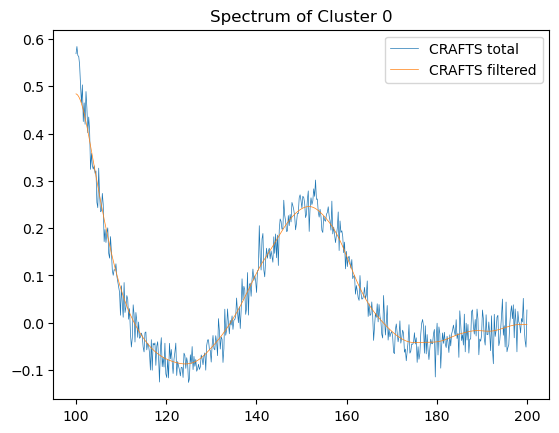

In [27]:
# Generate the filter you want to match to in the data
vel_width = np.max(x) - np.min(x)
if vel_width > 10:
    y_filtered = gaussian_filter(y, sigma=10)
else:
    y_filtered = gaussian_filter(y, sigma=vel_width)

fig = plt.figure()
plt.plot(x, y, label="CRAFTS total", lw=0.5)
plt.plot(x, y_filtered, label="CRAFTS filtered", lw=0.5)
plt.legend()
plt.title(f"Spectrum of Cluster 0")
plt.show()

In [34]:
# Use scipy to find all the peaks in the filter response
peaks = find_peaks_cwt(y_filtered, widths=20)
# Capture the prominence of each peak (how much does the peak stick up)
prominences, left_bases, right_bases = peak_prominences(y_filtered, peaks)
# Find the maximum prominence (which hopefully matches our signal)
max_prom_index = np.argmax(prominences)
peak_prominence = prominences[max_prom_index]
# Find the x-value that the peak occurred at
main_peak_x = x[peaks[max_prom_index]]
main_peak_y = y_filtered[peaks[max_prom_index]]
# the left base of the peak
main_lbase_x = x[left_bases[max_prom_index]]
main_lbase_y = y_filtered[left_bases[max_prom_index]]
# the right base of the peak
main_rbase_x = x[right_bases[max_prom_index]]
main_rbase_y = y_filtered[right_bases[max_prom_index]]
main_peak_plot = [
    main_peak_x,
    main_peak_y,
    main_lbase_x,
    main_lbase_y,
    main_rbase_x,
    main_rbase_y,
]
# Calculate the skew (a measure of asymmetry) of the peak
# left base: L, right base: R, peak position: P
# skew = |L + R - 2P| / |L - R|
skew = np.abs(main_peak_plot[2] + main_peak_plot[4] - 2 * main_peak_plot[0])
skew /= np.abs(main_peak_plot[2] - main_peak_plot[4])

/tmp/ipykernel_7863/1827331286.py:4: PeakPropertyWarning: some peaks have a prominence of 0
  prominences, left_bases, right_bases = peak_prominences(y_filtered, peaks)


In [33]:
find_peaks(y_filtered)

(array([ 55, 240]), {})

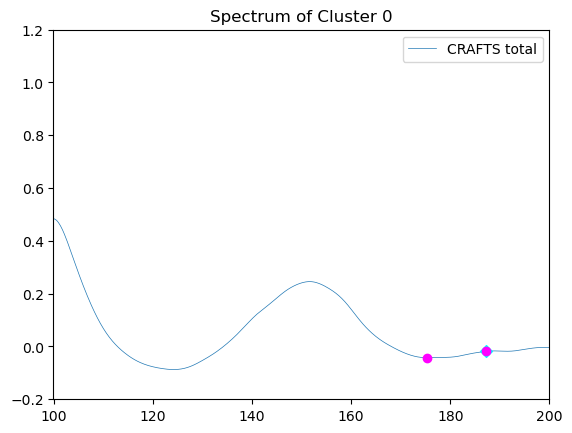

In [35]:
fig = plt.figure()
plt.plot(x, y_filtered, label="CRAFTS total", lw=0.5)
# plt.scatter(x[peaks], y_filtered[peaks], c="cyan", marker="+")
plt.scatter(
    main_peak_plot[0],
    main_peak_plot[1],
    c="cyan",
    marker="D",
    zorder=100,
)
# plt.scatter(x[left_bases], y_filtered[left_bases], c="magenta", marker="+")
plt.scatter(
    main_peak_plot[2],
    main_peak_plot[3],
    c="magenta",
    zorder=100,
)
# plt.scatter(x[right_bases], y_filtered[right_bases], c="magenta", marker="+")
plt.scatter(
    main_peak_plot[4],
    main_peak_plot[5],
    c="magenta",
    zorder=100,
)
plt.legend()
plt.xlim(np.min(x), np.max(x))
plt.ylim(-0.2, 1.2)
plt.title(f"Spectrum of Cluster 0")
plt.show()